In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

from sklearn.cluster import KMeans

pd.set_option("display.width", 100)

In [2]:
df = pd.read_csv("mallcustomers.csv")

In [3]:
print("Data types BEFORE cleaning:")
print(df.dtypes)
print()
print("Sample of raw Income values:")
print(df["Income"].head())
print()

Data types BEFORE cleaning:
CustomerID        int64
Gender           object
Age               int64
Income           object
SpendingScore     int64
dtype: object

Sample of raw Income values:
0    15,000 USD
1    15,000 USD
2    16,000 USD
3    16,000 USD
4    17,000 USD
Name: Income, dtype: object



In [4]:
#Problem 1: convert income to numeric value

In [5]:
df["Income"] = (
    df["Income"]
    .str.replace(",", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.strip()
    .astype(int)
)

In [6]:
# Problem 2: drop CustomerID

In [7]:
df = df.drop(columns=["CustomerID"])

In [8]:
# Problem 3.1: summary 

In [9]:
print("Summary statistics for Income and SpendingScore (raw scale):")
print(df[["Income", "SpendingScore"]].describe())
print()

Summary statistics for Income and SpendingScore (raw scale):
              Income  SpendingScore
count     200.000000     200.000000
mean    60560.000000      50.200000
std     26264.721165      25.823522
min     15000.000000       1.000000
25%     41500.000000      34.750000
50%     61500.000000      50.000000
75%     78000.000000      73.000000
max    137000.000000      99.000000



In [10]:
# Problem 3.2: normalization

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["Income", "SpendingScore"]])
X_scaled = pd.DataFrame(X_scaled, columns=["Income_z", "SpendingScore_z"])

In [12]:
print("Summary statistics after z-score normalization:")
print(X_scaled.describe())
print()

Summary statistics after z-score normalization:
           Income_z  SpendingScore_z
count  2.000000e+02     2.000000e+02
mean  -1.421085e-16    -1.465494e-16
std    1.002509e+00     1.002509e+00
min   -1.738999e+00    -1.910021e+00
25%   -7.275093e-01    -5.997931e-01
50%    3.587926e-02    -7.764312e-03
75%    6.656748e-01     8.851316e-01
max    2.917671e+00     1.894492e+00



In [13]:
# Problem 4: Apply K-means

In [14]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150)
plt.close()

In [15]:
print("Inertia by k:")
for k, inertia in zip(k_range, inertias):
    print(f"  k={k}: inertia={inertia:.2f}")
print()

Inertia by k:
  k=1: inertia=400.00
  k=2: inertia=269.69
  k=3: inertia=157.70
  k=4: inertia=108.92
  k=5: inertia=65.57
  k=6: inertia=55.06
  k=7: inertia=44.86
  k=8: inertia=37.23
  k=9: inertia=32.39
  k=10: inertia=29.98



In [16]:
#k starts to decrease less rapidly at 5

In [17]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

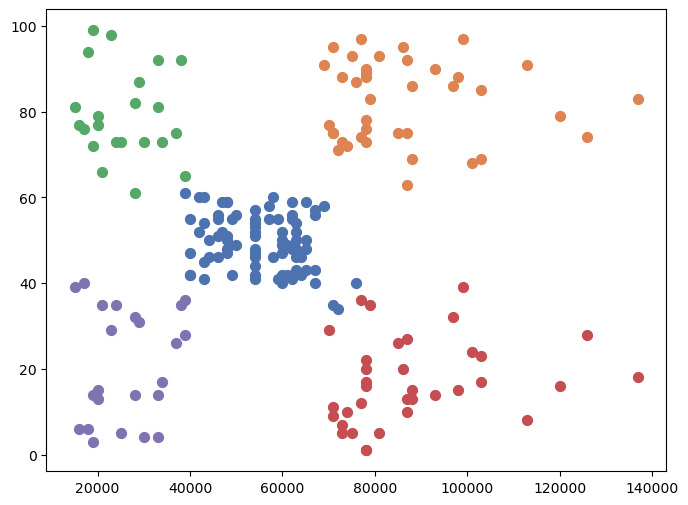

In [18]:
plt.figure(figsize=(8, 6))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
for cluster_id in range(optimal_k):
    subset = df[df["Cluster"] == cluster_id]
    plt.scatter(
        subset["Income"],
        subset["SpendingScore"],
        s=50,
        c=colors[cluster_id],
        label=f"Cluster {cluster_id}",
    )

In [19]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=250,
    c="black",
    marker="X",
    label="Centroids",
)

plt.xlabel("Annual Income (USD)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customer Segments (k=5)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cluster_plot.png", dpi=150)
plt.close()

In [20]:
print("Cluster sizes:")
print(df["Cluster"].value_counts().sort_index())
print()
print("Cluster centers (original scale - Income, SpendingScore):")
for i, c in enumerate(centroids_original):
    print(f"  Cluster {i}: Income=${c[0]:,.0f}, SpendingScore={c[1]:.1f}")
print()

Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster centers (original scale - Income, SpendingScore):
  Cluster 0: Income=$55,296, SpendingScore=49.5
  Cluster 1: Income=$86,538, SpendingScore=82.1
  Cluster 2: Income=$25,727, SpendingScore=79.4
  Cluster 3: Income=$88,200, SpendingScore=17.1
  Cluster 4: Income=$26,304, SpendingScore=20.9



In [21]:
#Problem 5: Evaluating the Clusters

In [22]:
cluster_names = {
    0: "Standard (Mid Income, Mid Spending)",
    1: "Target / Premium (High Income, High Spending)",
    2: "Impulsive (Low Income, High Spending)",
    3: "Careful (High Income, Low Spending)",
    4: "Frugal (Low Income, Low Spending)",
}
df["ClusterName"] = df["Cluster"].map(cluster_names)

# Create Male/Female dummy variables
df["Male"] = (df["Gender"] == "Male").astype(int)
df["Female"] = (df["Gender"] == "Female").astype(int)

profile = df.groupby(["Cluster", "ClusterName"]).agg(
    N=("Cluster", "size"),
    MeanAge=("Age", "mean"),
    PctMale=("Male", "mean"),
    PctFemale=("Female", "mean"),
    MeanIncome=("Income", "mean"),
    MeanSpendingScore=("SpendingScore", "mean"),
).reset_index()
profile["PctMale"] = (profile["PctMale"] * 100).round(1)
profile["PctFemale"] = (profile["PctFemale"] * 100).round(1)
profile["MeanAge"] = profile["MeanAge"].round(1)
profile["MeanIncome"] = profile["MeanIncome"].round(0)
profile["MeanSpendingScore"] = profile["MeanSpendingScore"].round(1)

print("Cluster demographic profile:")
print(profile.to_string(index=False))
print()

Cluster demographic profile:
 Cluster                                   ClusterName  N  MeanAge  PctMale  PctFemale  MeanIncome  MeanSpendingScore
       0           Standard (Mid Income, Mid Spending) 81     42.7     40.7       59.3     55296.0               49.5
       1 Target / Premium (High Income, High Spending) 39     32.7     46.2       53.8     86538.0               82.1
       2         Impulsive (Low Income, High Spending) 22     25.3     40.9       59.1     25727.0               79.4
       3           Careful (High Income, Low Spending) 35     41.1     54.3       45.7     88200.0               17.1
       4             Frugal (Low Income, Low Spending) 23     45.2     39.1       60.9     26304.0               20.9

